In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv(r"C:\Users\Ravi Daliparthy\Downloads\diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Classification Report:               precision    recall  f1-score   support

           0       0.83      0.67      0.74        15
           1       0.38      0.60      0.46         5

    accuracy                           0.65        20
   macro avg       0.60      0.63      0.60        20
weighted avg       0.72      0.65      0.67        20

Confusion Matrix: [[10  5]
 [ 2  3]]


<Axes: >

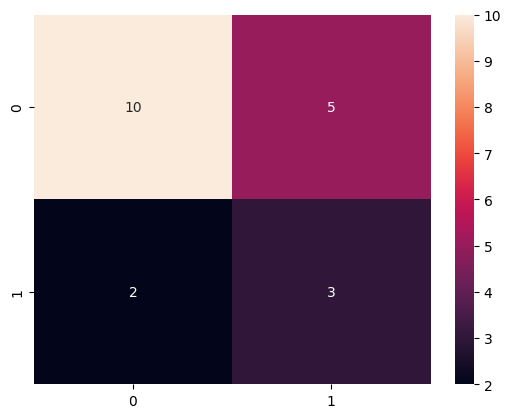

In [2]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import seaborn as sns

X=df.drop('Outcome',axis=1)
y=df['Outcome']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=20,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

knn=KNeighborsClassifier(5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

print("Classification Report:",classification_report(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)


Highest Accuracy:  0.7
High K_Value:  8


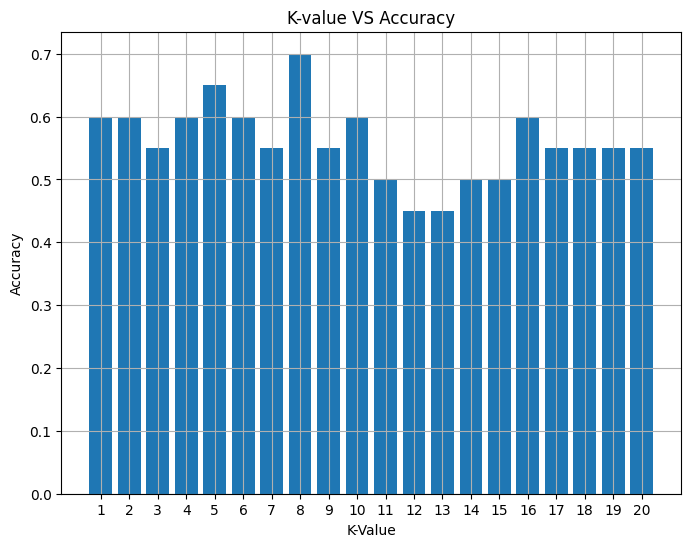

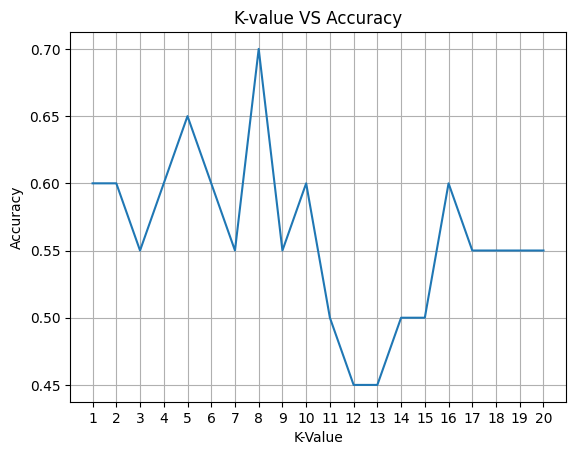

In [3]:
k_values=range(1,21)
accuracies=[]
for k in k_values:
    knn=KNeighborsClassifier(k)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    accuracies.append(accuracy)

high_accuracy=max(accuracies)
high_k_value=k_values[accuracies.index(high_accuracy)]
print("Highest Accuracy: ",high_accuracy)
print("High K_Value: ",high_k_value)

plt.figure(figsize=(8,6))
plt.bar(k_values,accuracies)
plt.xlabel('K-Value')
plt.ylabel('Accuracy')
plt.title('K-value VS Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

plt.plot(k_values,accuracies)
plt.xlabel('K-Value')
plt.ylabel('Accuracy')
plt.title('K-value VS Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

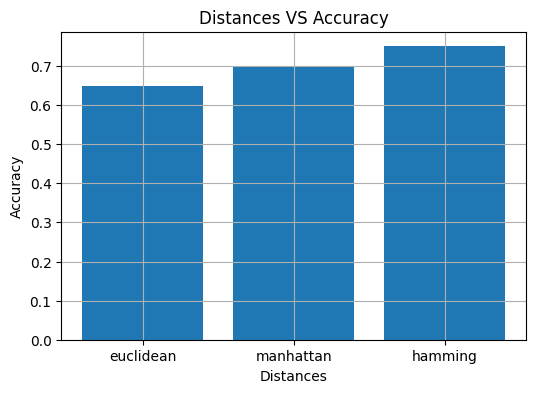

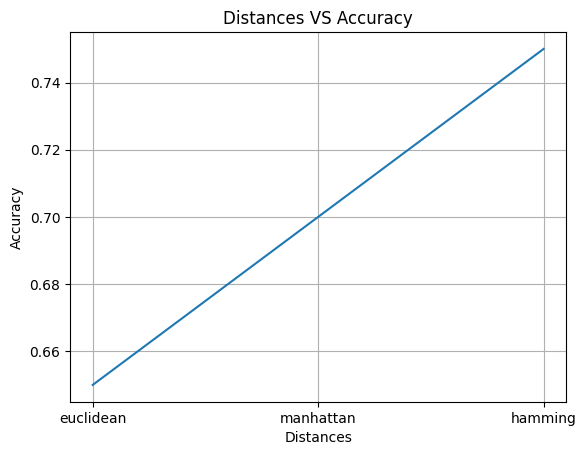

In [4]:
distances=['euclidean','manhattan','hamming']
accuracies=[]
for dist in distances:
    knn=KNeighborsClassifier(5,metric=dist)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    accuracies.append(accuracy)

plt.figure(figsize=(6,4))
plt.bar(distances,accuracies)
plt.xlabel('Distances')
plt.ylabel('Accuracy')
plt.title('Distances VS Accuracy')
plt.grid(True)
plt.show()

plt.plot(distances,accuracies)
plt.xlabel('Distances')
plt.ylabel('Accuracy')
plt.title('Distances VS Accuracy')
plt.grid(True)
plt.show()

Classification Report:               precision    recall  f1-score   support

           0       0.67      0.53      0.59        15
           1       0.12      0.20      0.15         5

    accuracy                           0.45        20
   macro avg       0.40      0.37      0.37        20
weighted avg       0.53      0.45      0.48        20

Confusion Matrix: [[8 7]
 [4 1]]


<Axes: >

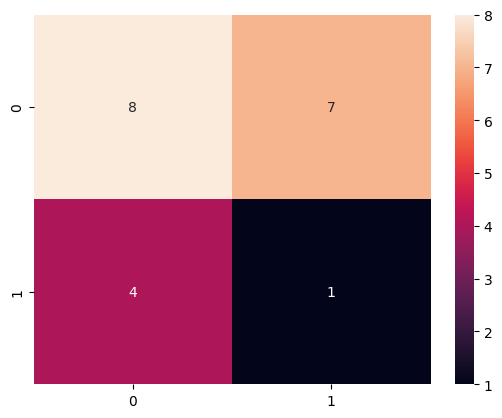

In [5]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
x_train_pca=pca.fit_transform(X_train)
x_test_pca=pca.transform(X_test)

knn=KNeighborsClassifier(5)
knn.fit(x_train_pca,y_train)
y_pred=knn.predict(x_test_pca)

print("Classification Report:",classification_report(y_test,y_pred))
print("Confusion Matrix:",confusion_matrix(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

<Figure size 1000x800 with 0 Axes>

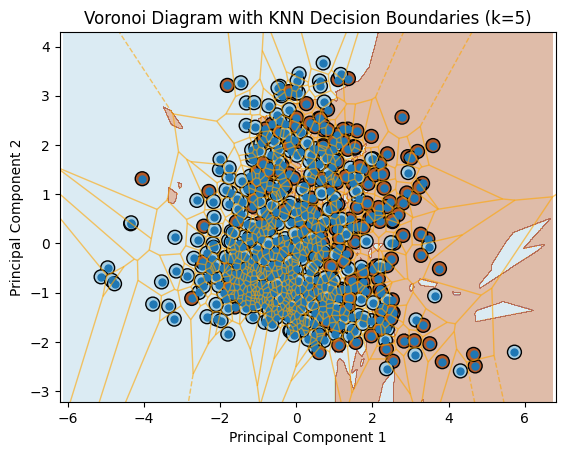

In [6]:
from scipy.spatial import Voronoi, voronoi_plot_2d

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)

# Create a meshgrid for the Voronoi diagram
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for each point in the meshgrid
Z = knn.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot the Voronoi diagram
plt.figure(figsize=(10, 8))
vor = Voronoi(X_train_pca)
voronoi_plot_2d(vor, show_vertices=False, line_colors='orange', line_width=1, line_alpha=0.6, point_size=10)

# Plot the decision boundaries
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.Paired)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=plt.cm.Paired, edgecolor='k', s=100)
plt.title('Voronoi Diagram with KNN Decision Boundaries (k=5)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [7]:
from scipy.spatial import Voronoi, voronoi_plot_2d

# y=df['Outcome'].values
# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)  # Converts "Normal" → 0, "Overweight" → 1, etc.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(5, metric='euclidean')
knn.fit(X_train, y_train)


KNeighborsClassifier(metric='euclidean')

In [ ]:
# Generate Voronoi diagram
vor = Voronoi(X_train)  # Creating Voronoi diagram from training points

# Plot Voronoi regions
plt.figure(figsize=(10, 6))
voronoi_plot_2d(vor, show_vertices=False, line_colors='black', line_width=1, point_size=2)

# Scatter plot of data points (now with numerical labels)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolors='k', label="Train Data")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, marker='s', edgecolors='k', label="Test Data")

# Labels and title
plt.xlabel('Weight (Scaled)')
plt.ylabel('Height (Scaled)')
plt.title(f'Voronoi Diagram for KNN (k={k}, Euclidean)')
plt.legend()
plt.show()